### $\textbf{FE5213 Lab 1: Asset Pricing}$


##### Date: January 16, 2026

<br>


Before we start, it would be helpful if you have access to -`Jupyter Notebook` on your computer; see __[QuantEcon](https://python-programming.quantecon.org/getting_started.html)__ for instructions on installing Anaconda and accessing the notebook. 

If you have any questions, feel free to email me aying.luo@u.nus.edu

#### $\textbf{Short Summary}$

In this lab we use **ex-dividend** pricing. The core recursion is

$$
p_t = \mathbb{E}_t\left[ M_{t+1}\,(d_{t+1} + p_{t+1}) \right]\tag{1.1}
$$


By changing the assumptions of $ M_{t+1}$  and $d_{t+1}$, this lab follows a **single logical chain**:

**Step 1 (Present value: constant growth rate, constant SDF)** → **Step 2 (Markov infinite state model: state-dependent dividend growth)** → **Step 3 (Lucas tree: state-dependent SDF)**

(they are the same model but tweak different assumptions. step 2 assumes growth rate is not constant, depends on state/time period, step 3 assumes discount factor depends on state/time period)

#### $\textbf{Learning objectives}$
By the end of this lab, you should be able to:

1. Discretize an AR(1) state process via **Tauchen** and simulate states/dividends.
2. Compute price–dividend ratio under **Neutral Risk Case** ($M_{t+1}=\beta$) when cash flows grow at (i) constant rate, (ii) state-dependent rate.
3. Compute the **Lucas tree** price–dividend ratio under CRRA preferences (state-dependent SDF).

#### $\textbf{Setup: packages}$

We will use:

- `numpy` for arrays and numerical work
- `matplotlib` for plotting
- `scipy.linalg.solve` for solving linear systems (stable)
- `quantecon` for Tauchen discretization and Markov chains

In [ ]:
# 1. Install relevant packages (run once).
#
# In Jupyter, prefer %pip (not !pip) because %pip installs into the *current kernel's* Python environment.
# This avoids the common issue: "pip install succeeded but import fails" (installed into a different env).
#
# Windows (run in Anaconda Prompt or Command Prompt, not in Jupyter Notebook):
#   D:\Software\Anaconda\python.exe -m ipykernel install --user --name anaconda-base --display-name "Python (Anaconda)"
#
# macOS (Terminal):
#   python3 -m ipykernel install --user --name anaconda-base --display-name "Python (Anaconda)"
#
# After installing the kernel, switch kernel in Jupyter: Kernel -> Change Kernel.
#
# Run once inside Jupyter Notebook (recommended):

# !conda install quantecon
#%pip install quantecon


Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.1.1 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


In [1]:
# 2. Import libraries
#
# numpy: numerical arrays, math
# matplotlib: plotting
# eigvals: eigenvalues for spectral radius checks
# solve: stable linear-system solver (preferred over matrix inverse)
# quantecon: Tauchen discretization + MarkovChain tools

import numpy as np
import matplotlib.pyplot as plt

from numpy.linalg import eigvals
from scipy.linalg import solve

import quantecon as qe

# Fix the random seed so simulations are reproducible (same output each run)
np.random.seed(123)

print("quantecon version:", qe.__version__)


quantecon version: 0.10.1


---

### $\textbf{Step 1: From the general asset pricing equation to PV}$

In this course, we start from the **general (ex-dividend) pricing equation**

$$
p_t = \mathbb{E}_t\left[ M_{t+1}\,(d_{t+1} + p_{t+1}) \right].\qquad t = 0, 1, \dots, T-1.
$$

- $p_t$ is the **ex-dividend** price at time $t$ (buy today, dividends start next period)
- $d_{t+1} + p_{t+1}$ is the **one-period payoff** (next period dividend + resale price)
- $M_{t+1}$ is the **stochastic discount factor (SDF)**: it captures how valuable payoffs are across future states

The **price-dividend ratio** $ v_t := p_t / d_t $.

<a id='equation-pdex'></a>
$$
v_t = {\mathbb E}_t \left[ M_{t+1} \frac{d_{t+1}}{d_t} (1 + v_{t+1}) \right] \tag{1.1}
$$

By introducing $v_t$, we can factor out the scale of dividends. In addition, it is easier to solve.
#### $\textbf{1.1 Cum-dividend vs ex-dividend}$
Sometimes notes use **cum-dividend** prices.

$$
p_t^{cum} = d_t + \mathbb{E}_t\left[ M_{t+1} \, p_{t+1}\right].\tag{1.2}
$$


#### $\textbf{1.2 PV under cum-dividend}$

Based on equation(1.2), we impose two simplifying assumptions:


1. **Constant discounting:** $M_{t+1}=\beta$ for all $t$
2. **Constant growth rate:** $d_{t+1} = gd_t$

Then the general equation becomes the familiar recursion

$$
p_t = d_t + \beta\,p_{t+1}, \qquad t=0,1,\dots,T-1.
$$

> **Note:** This equation is the same with equation (11.1) in __[Present Value](https://intro.quantecon.org/pv.html)__. In the PV section, the recursion is written in a **cum-dividend** style. You can always translate it to the ex-dividend version using the identity above.

We guess the price-dividend ratio is constant:
$$
v = \frac{1}{1 - \beta g }
$$

In [ ]:
# from p_t = d_t + beta * p_t+1
# divide d_t on both sides and use some chain method by getting d_t+1 in ratio 1, 
# to get v_t = 1 + beta * v_t+1 * g (note v_t = v_t+1 * g)
# (1 - beta * g)(v) = 1

# Let's start with a simple example: deterministic dividend growth (Gordon formula)
# through this example, we will know some basic operations about numpy and matplotlib

# 1. Define parameters
beta = 0.97       # discount factor
g = 1.02          # gross growth rate
d0 = 1.0          # initial dividend

# 2. Price-dividend ratio (constant under deterministic growth)
v = 1/(1-beta*g)
print("v (price-dividend ratio) =", v)

# What if we increase beta or g?
# future div becomes more valuable (def of discount factor = how much u value the future), 
# so pay high price to get this stock (cos we are so patient, wont give up so easily)


v (price-dividend ratio) = 94.33962264150895


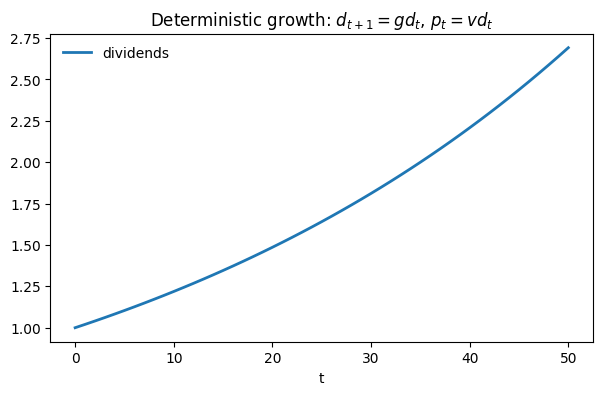

In [3]:
# 3. Build a deterministic dividend path and implied price path

# set time horizon
T = 50                      

# pre-allocate an empty array to store dividends from 0 to T
d = np.empty(T+1)

# pre-allocate an empty array to store price from 0 to T
p = np.empty(T+1)

# set the initial dividend
d[0] = d0                   

# given a constant gross growth rate g and initial dividend, compute dividend from 1 to T
for t in range(T): # 0,1,...,T
    d[t+1] = d[t] * g
    

# given P/D ratio, compute price from 0 to T
p = v * d               

# 4. Plot dividends and prices

# set figure size (7,4)
plt.figure(figsize=(7,4))

# plot dividend path
plt.plot(d, lw = 2, label = "dividends")

# add legend, title and xlabel
plt.legend(frameon=False)
plt.title("Deterministic growth: $d_{t+1}=g d_t$, $p_t=v d_t$")
plt.xlabel("t")
plt.show()

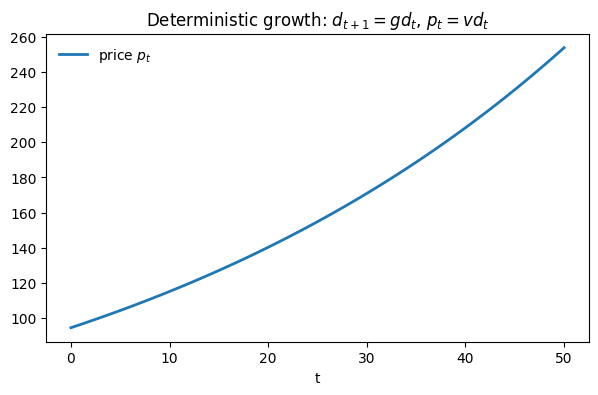

In [4]:
# similarly, plot price path
plt.figure(figsize=(7,4))   # set figure size (7,4)
plt.plot(p, lw=2, label="price $p_t$")
plt.legend(frameon=False)
plt.title("Deterministic growth: $d_{t+1}=g d_t$, $p_t=v d_t$")
plt.xlabel("t")
plt.show()

---
### $\textbf{Step 2: Markov dividend growth with constant SDF}$

**Now we change the key assumption: dividend growth is state-dependent**

$$
d_{t+1} = g_{t+1}\, d_t.
$$
The stochastic growth factor $ \{g_t\} $ is given by

$$
g_t = g(X_t), \quad t = 1, 2, \ldots
$$

where

1. $ \{X_t\} $ is a finite Markov chain with state space $ S $ and
  transition probabilities  
  $$
  P(x, y) := \mathbb P \{ X_{t+1} = y \,|\, X_t = x \}
     \qquad (x, y \in S)
  $$
1. $ g $ is a given function on $ S $ taking nonnegative values  

**But we still keep discounting constant**

$$
M_{t+1}=\beta.
$$


**What changed relative to Step 1?**
- Cash flows are now **stochastic** (depend on the Markov state)
- Discounting remains **constant**

#### $\textbf{2.1 Discretize an AR(1) state using Tauchen}$

We approximate a continuous AR(1)

$$X_{t+1}=
\rho X_t + 
\epsilon_{t+1},\ 
\epsilon_{t+1}\sim N(0,\sigma^2)$$

with a finite-state Markov chain:
- state grid `mc.state_values`
- transition matrix `mc.P`

In [11]:
# 2.1 Discretize a continuous AR(1) state process using Tauchen.

# Tauchen approximates it by a finite-state Markov chain with:
#   - mc.state_values: grid of possible X values (n points)
#   - mc.P: transition matrix, P[i,j] = Prob(X_{t+1}=x_j | X_t=x_i)


rho, sigma = 0.96, 0.02

# set the number of discrete states (grid size)
n = 25 #(must be odd number so that median is an int)
#only two states for X_t (easiest) 

# use qe.tauchen to construct a markov chain
# need these 3 params to get markov chain, number of states, rho (coef of X_t) and sigma (var of iid error)
mc = qe.tauchen(n, rho, sigma)

x = mc.state_values    # grid of states (length n)
P = mc.P               # transition matrix (n x n)

print("state grid length:", len(x))
print("P shape:", P.shape)


state grid length: 25
P shape: (25, 25)


In [12]:
# Sanity check: each row of a transition matrix is a probability distribution.
# So each row should sum to 1 (up to tiny numerical error).

P.sum(axis=1).min(), P.sum(axis=1).max()


(np.float64(0.9999999999999993), np.float64(1.0000000000000004))

#### $\textbf{2.2 Simulate states → growth → dividends}$

We simulate $X_t$, set $g_t=\exp(X_t)$, and build dividends by cumulative product (assume $d_0=1$).

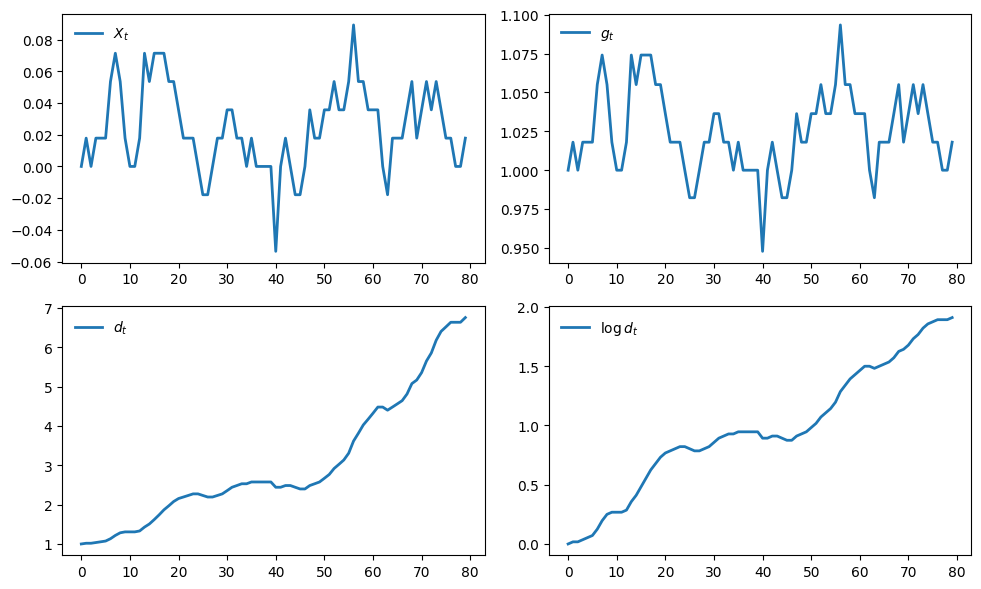

In [13]:
# 2.2 Simulate the Markov state and build dividend growth + dividend levels.
#
# We will simulate:
#   X_t        : Markov state
#   g_t = exp(X_t) : (gross) dividend growth rate
#   d_t        : dividend level, built from cumulative growth (assume d_0 = 1)

sim_length = 80

# Simulate a length-80 path of states; start from the median grid point
x_series = mc.simulate(sim_length, init = np.median(mc.state_values))

# Map state to growth: g_t = exp(X_t)
g_series = np.exp(x_series)

# Build dividends: d_t = prod_{s=0}^{t-1} g_s, assuming d_0 = 1
# d_t = d_0 * prod_{s=1}^{t} g_s
d_series = np.cumprod(g_series)

# Put the four series together for plotting
series = [x_series, g_series, d_series, np.log(d_series)]
labels = ['$X_t$', '$g_t$', '$d_t$', r'$\log d_t$']

# Create a 2x2 grid of subplots
fig, axes = plt.subplots(2, 2, figsize=(10, 6))

# axes is a 2D array (2x2). flatten() turns it into a 1D list of 4 axes,
# so we can iterate over them easily.
# zip(...) lets us loop over (axis, series, label) together.
for ax, s, label in zip(axes.flatten(), series, labels):
    ax.plot(s, lw=2, label=label)
    # Add a legend for this subplot
    # frameon=False removes the legend box; loc sets the legend position
    ax.legend(frameon=False, loc='upper left')

# Automatically adjust spacing between subplots to avoid overlapping text
plt.tight_layout()

plt.show()

#### $\textbf{2.3 Price–dividend ratio under constant SDF}$

Define $v_t=p_t/d_t$. We guess that, in the current case, $ v_t $ is a fixed function of the state $ X_t $.


With $M_{t+1}=\beta$ and $d_{t+1}/d_t=g(X_{t+1})$,

$$
v(X_t) = \beta {\mathbb E}_t [ g(X_{t+1}) (1 + v(X_{t+1})) ]
$$

If we condition on $ X_t = x $, this becomes

$$
v(x) = \beta \sum_{y\in S} g(y)\,(1+v(y))\,P(x,y).
$$

Let $K(x,y)=g(y)P(x,y)$. In matrix form,

$$
(I-\beta K)v = \beta K\mathbf{1}.
$$

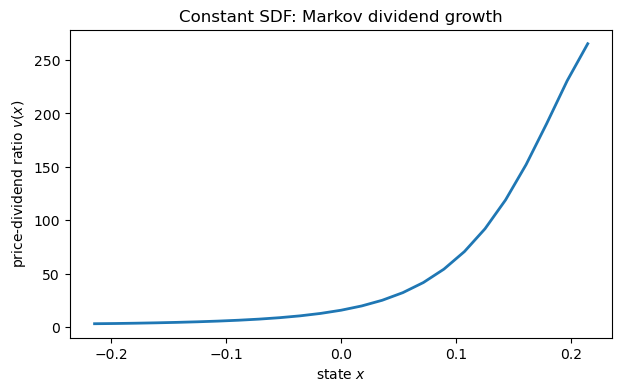

In [13]:
# 2.3 Price-dividend ratio under constant SDF (risk-neutral discounting)

# We solve this linear system for v.

beta = 0.9

# Broadcasting trick:
#   np.exp(x) has shape (n,)
#   P has shape (n,n)
#   P * np.exp(x) multiplies each column j by exp(x_j), giving K(i,j)=P(i,j)*g(x_j)
K = P * np.exp(x)

# Spectral radius condition ensures (I - beta K) is invertible and values are finite.
# It's the matrix analogue of the Gordon condition beta*g < 1.
warning_message = "Spectral radius condition fails"
assert np.max(np.abs(eigvals(K))) < 1 / beta, warning_message

I = np.identity(n)
ones = np.ones(n)

# Solve (I - beta K) v = beta K 1
v_constSDF =

plt.figure(figsize=(7,4))
plt.plot(x, v_constSDF, lw=2)
plt.xlabel("state $x$")
plt.ylabel("price-dividend ratio $v(x)$")
plt.title("Constant SDF: Markov dividend growth")
plt.show()


**Plot intuition (cash-flow effect):** in persistent states, higher current $x$ suggests higher future growth → higher expected future dividends → higher $v(x)$ (often upward sloping).

**Checkpoint:** Increase `beta` or `rho` and re-run. When does the spectral radius check fail?

**Spectral radius:** the check fails usually happens when you increase `beta`
(weaker discounting) and/or increase `rho` (more persistence) too much.

**Price diverges:** the infinite-horizon present value does not converge, so
the price-dividend ratio `v(x)` is not finite. In practice, the linear solve
becomes unstable and `v` can blow up or return `inf`/`nan`.

### $\textbf{Step 3: Lucas tree: risk enters the discount factor}$

Now we change the key assumption: **discounting is state-dependent**.

As in [[Lucas, 1978](https://python.quantecon.org/zreferences.html#id201)], we suppose that the stochastic discount factor takes the form


<a id='equation-lucsdf'></a>
$$
M_{t+1} = \beta \frac{u'(c_{t+1})}{u'(c_t)} \tag{81.11}
$$

With CRRA utility, the SDF is

$$
M_{t+1}=\beta \left(\frac{c_{t+1}}{c_t}\right)^{-\gamma}.
$$

In the Lucas tree equilibrium, consumption equals dividends, so $c_{t+1}/c_t = g(X_{t+1})$. Then

$$
M_{t+1}=\beta\, g(X_{t+1})^{-\gamma}.
$$

The price–dividend ratio satisfies

$$
v(x)=\beta \sum_{y\in S} g(y)^{1-\gamma}(1+v(y))P(x,y).
$$

Let $J(x,y)=P(x,y)g(y)^{1-\gamma}$. Then

$$
(I-\beta J)v = \beta J \mathbf{1}.
$$

**What changed relative to Step 2?**
- Cash flows are still stochastic
- Discounting is now **also stochastic** (via marginal utility)

**Plot intuition:** two forces can compete  
- **cash-flow effect** (higher growth → higher future dividends)  
- **discount-rate effect** (higher growth → lower marginal utility → lower SDF → heavier discounting)

Depending on $\gamma$, the slope of $v(x)$ can flip.

#### $\textbf{3.1 Compute the Lucas tree $v(x)$}$

We store primitives in a class and compute the Lucas tree $v(x)$ using the linear system above.

In [2]:

# Why a class?
# - It bundles the model primitives (parameters, Markov chain, functions) into one object.
# - This keeps the code clean: use model.beta, model.mc.P, model.test_stability(...) instead of passing many variables.


class AssetPriceModel:
    """Stores primitives for the Lucas tree asset pricing model.

    Parameters
    ----------
    β : float
        Discount factor.
    mc : MarkovChain
        Markov chain object containing transition matrix P and state grid.
    γ : float
        Risk aversion coefficient (CRRA).
    g : callable
        Maps states to growth rates, e.g. g(x)=exp(x).

    Notes
    -----
    In the Lucas tree equilibrium, consumption growth equals dividend growth,
    so the SDF depends on growth and risk aversion.
    """
    
    
    # - The initializer (constructor).
    def __init__(self, β=0.96, mc=None, γ=2.0, g=np.exp):
        self.β, self.γ = β, γ
        self.g = g

        # A default process for the Markov chain (used only if mc is not provided)
        if mc is None:
            self.n = 25
            self.ρ = 0.9
            self.σ = 0.02
            self.mc = qe.tauchen(n, self.ρ, self.σ)
        else:
            self.mc = mc

        # Number of states
        self.n = self.mc.P.shape[0]

    def test_stability(self, Q):
        """Check the spectral radius condition for a matrix Q.

        We need max|eig(Q)| < 1/β so that (I - βQ) is invertible and
        the infinite-horizon valuation is finite.
        """
        sr = np.max(np.abs(eigvals(Q)))
        if not sr < 1 / self.β:
            msg = f"Spectral radius condition failed with radius = {sr}"
            raise ValueError(msg)


def tree_price(ap):
    """Compute the Lucas tree price-dividend ratio v(x).

    For CRRA preferences, with consumption growth equal to dividend growth,
    the pricing equation implies

        v(x) = β * sum_y P(x,y) * g(y)^(1-γ) * (1 + v(y))

    Define J(x,y) = P(x,y) * g(y)^(1-γ). Then

        (I - βJ) v = βJ 1

    We solve this linear system for v.
    """
    β, γ, P, y = ap.β, ap.γ, ap.mc.P, ap.mc.state_values

    # J(i,j) = P(i,j) * g(y_j)^(1-γ)
    J = P * ap.g(y)**(1 - γ)

    # Ensure a unique finite solution exists
    ap.test_stability(J)

    I = np.identity(ap.n)
    ones = np.ones(ap.n)

    v = solve(I - β * J, β * J @ ones)
    return v


#### $\textbf{3.2 Plot $v(x)$ for different risk aversion levels $\gamma$}$

- Compare slopes across $\gamma$.  
- Larger $\gamma$ makes the SDF more sensitive to growth, strengthening the discount-rate effect.

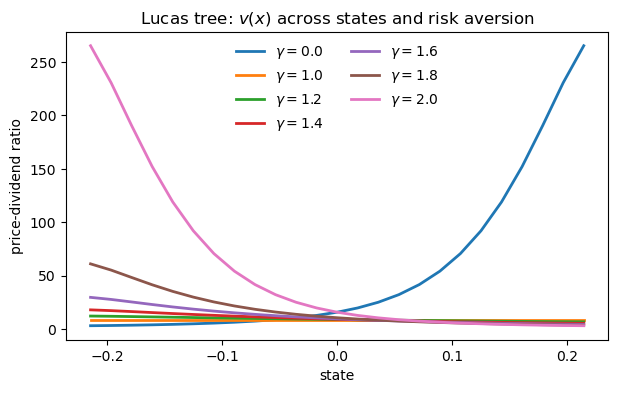

In [16]:
# Plot Lucas tree price-dividend ratios across states for different risk aversion levels gamma.

beta = 0.9
gammas = [0.0, 1.0, 1.2, 1.4, 1.6, 1.8, 2.0]

plt.figure(figsize=(7,4))
for gamma in gammas:
    ap = AssetPriceModel(β=beta, mc=mc, γ=gamma, g=np.exp)
    v_lucas = tree_price(ap)
    plt.plot(mc.state_values, v_lucas, lw=2, label=rf'$\gamma={gamma}$')

plt.xlabel("state")
plt.ylabel("price-dividend ratio")
plt.title("Lucas tree: $v(x)$ across states and risk aversion")
plt.legend(frameon=False, ncol=2)
plt.show()

# Intuition:
# - Larger gamma makes the SDF more sensitive to consumption/dividend growth.
# - This strengthens the "discount-rate effect" and can change the slope of v(x).

**Intuition:**
- $\gamma=0$: risk-neutral → should resemble Step 2 (constant discounting).
- $\gamma=1$: log utility → $v(x)$ becomes (approximately) constant across states.
- $\gamma>1$: the discount-rate effect can dominate → $v(x)$ may slope downward.
